In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.radar_parser import radar9_parser
from utils.get_range_FFT import get_range_FFT
from utils.range_cfar import range_cfar
from utils.get_doppler import get_doppler, plot_dopler
from utils.get_max_velocity import get_max_velocity

In [2]:
# =============================================================================
# SCRIPT PRINCIPAL
# =============================================================================
c = 3e8
file = "../data/kelly/A151P148R1S5D0.bin"


In [3]:
RADAR_PARAM, radar_data = radar9_parser(file)

[     12    1036    2060 ... 2556940 2557964 2558988]
(2560000,)


In [4]:
RADAR_PARAM

{'ch': np.uint16(1),
 'frequ_start': 9600000000,
 'frequ_stop': 10000000000,
 'sweep_time': np.float64(0.004),
 'NTS': 1024,
 'bw': 400000000,
 'fc': 9800000000.0,
 'fs': np.float64(256000.0),
 'num_chirps': 2500}

In [5]:
radar_data

array([[-169.57335859+282.85979005j, -287.57335859-253.70495488j,
        -249.57335859-235.58671417j, ..., -251.57335859-188.98077418j,
        -251.57335859-187.00995279j, -253.57335859-177.60034045j],
       [-185.57335859+258.03826627j,  162.42664141-374.24505485j,
         204.42664141-359.19367585j, ...,  232.42664141-277.04836176j,
         230.42664141-274.46742795j,  228.42664141-265.80606132j],
       [-199.57335859+236.45979886j,  350.42664141-267.45244164j,
         396.42664141-248.6049088j , ...,  342.42664141-149.940016j  ,
         342.42664141-150.66512267j,  342.42664141-143.32875057j],
       ...,
       [ 122.42664141 -88.38521523j,  166.42664141 -71.22979464j,
         170.42664141 -61.68009235j, ...,  186.42664141 -26.54673772j,
         190.42664141 -17.92567296j,  188.42664141+245.4256047j ],
       [  32.42664141 -78.46629463j,   76.42664141 -60.22339387j,
          76.42664141 -52.05325065j, ...,  100.42664141  +4.30294943j,
         102.42664141 +14.09474762j

In [6]:
MIN_RANGE_FOR_DOPPLER_DETECTION = 2
MAX_RANGE_FOR_DOPPLER_DETECTION = 5

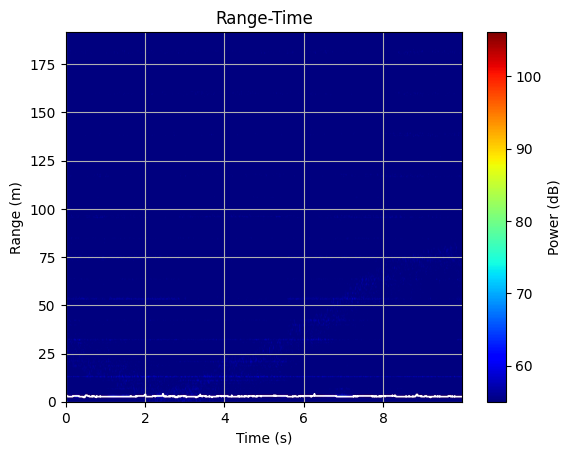

In [7]:

range_FFT = get_range_FFT(radar_data)
M, W, bin_indl, bin_indu = range_cfar(RADAR_PARAM, range_FFT)
    

In [8]:

# === paramètres Doppler ===

MD = {}

MD["PRF"] = 1 / RADAR_PARAM["sweep_time"]
MD["TimeWindowLength"] = 256
MD["OverlapFactor"] = 0.95
MD["OverlapLength"] = round(MD["TimeWindowLength"] * MD["OverlapFactor"])

MD["Pad_Factor"] = 4
MD["FFTPoints"] = MD["Pad_Factor"] * MD["TimeWindowLength"]

MD["DopplerBin"] = MD["PRF"] / MD["FFTPoints"]

MD["DopplerAxis"] = np.arange(
    -MD["PRF"]/2,
    MD["PRF"]/2,
    MD["DopplerBin"]
)

MD["WholeDuration"] = range_FFT.shape[1] / MD["PRF"]

# === axe temps ===

data_spec_MTI2 = get_doppler(RADAR_PARAM, MD, range_FFT, M, W, bin_indl, bin_indl)

MD["TimeAxis"] = np.linspace(
    0,
    MD["WholeDuration"],
    data_spec_MTI2.shape[1]
)


c:\Users\Kelly\akelly\ENSEA\stabilometrie\synchro_plateforme_de_force\stabilogram_extraction\scripts\utils\get_doppler.py:72: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, S = spectrogram(


c:\Users\Kelly\akelly\ENSEA\stabilometrie\synchro_plateforme_de_force\stabilogram_extraction\scripts\utils\get_doppler.py:17: RuntimeWarning: divide by zero encountered in log10
  20*np.log10(np.abs(doppler_data)),


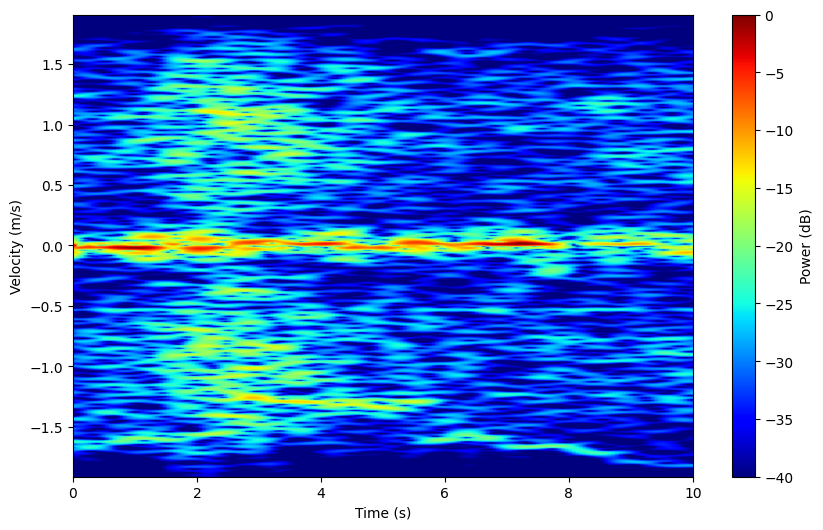

In [9]:
plot_dopler(RADAR_PARAM, MD, data_spec_MTI2)

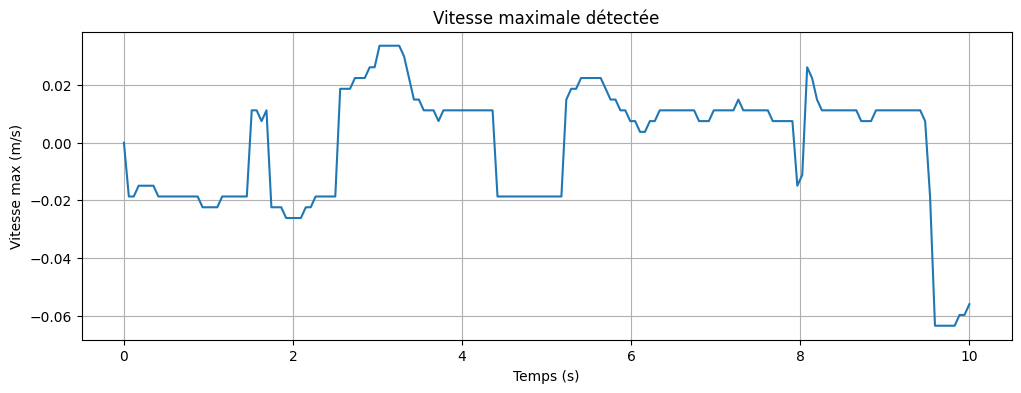

In [10]:
get_max_velocity(RADAR_PARAM, MD, data_spec_MTI2, "../data/kelly/Y_vitesse.csv")